# Business Understanding

## Project Domain

Kumpulan data ini berisi data simulasi untuk diagnosis tumor otak, perawatan, dan detail pasien. Kumpulan data ini terdiri dari 20 kolom dan 20.000 baris, yang menyediakan informasi seperti demografi pasien, karakteristik tumor, gejala, detail perawatan, dan persyaratan tindak lanjut. Kumpulan data ini dirancang untuk proyek pembelajaran mesin yang berfokus pada prediksi jenis dan tingkat keparahan tumor otak, serta pemahaman berbagai metode perawatan dan hasil pasien.

## Problem Statements

Tumor otak merupakan salah satu penyakit yang berisiko tinggi dan membutuhkan penanganan cepat dan tepat. Namun, proses diagnosis manual seringkali memerlukan waktu, tenaga ahli, dan dapat rentan terhadap kesalahan manusia. Oleh karena itu, dibutuhkan sistem otomatis yang mampu mengklasifikasi jenis tumor otak secara akurat untuk membantu proses diagnosis.



## Goals

Tujuan dari proyek ini adalah untuk:

1.Mengembangkan model machine learning atau deep learning yang dapat mengklasifikasikan tipe tumor otak berdasarkan data pasien.

2.Meningkatkan akurasi klasifikasi tumor untuk membantu profesional medis dalam proses diagnosis.

3.Mengevaluasi kinerja model menggunakan metrik seperti akurasi dan matriks kebingungan






## Solution Statements

Solusi yang ditawarkan adalah membangun dan melatih model klasifikasi tumor otak menggunakan dataset dari Kaggle. Proyek ini mencakup tahap:

1.Pra-pemrosesan data (data cleaning, normalisasi)

2.Eksplorasi data (EDA)

3.Pelatihan model menggunakan teknik deep learning (Keras)

4.Evaluasi performa model
Hasil dari model ini diharapkan mampu mengklasifikasikan tumor dengan akurasi yang tinggi untuk mendukung pengambilan keputusan medis.



# Data Understanding

## Import data dari kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rannggaaa","key":"b3971d55412e868293ef76fb71b4841e"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [3]:
!kaggle datasets download -d miadul/brain-tumor-dataset

Dataset URL: https://www.kaggle.com/datasets/miadul/brain-tumor-dataset
License(s): MIT


In [4]:
!mkdir brain-tumor-dataset
!unzip brain-tumor-dataset.zip -d brain-tumor-dataset
!ls brain-tumor-dataset

Archive:  brain-tumor-dataset.zip
  inflating: brain-tumor-dataset/brain_tumor_dataset.csv  
brain_tumor_dataset.csv


## Import Library yang dibutuhkan

In [74]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
import seaborn as sb # Import the seaborn library and give it the alias "sb"
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn with the correct alias
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model # Import the plot_model function
from sklearn.metrics import accuracy_score, confusion_matrix


import tensorflow as tf
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

## Exploratory Data Analysis

In [6]:
df = pd.read_csv('/content/brain-tumor-dataset/brain_tumor_dataset.csv')

In [7]:
df.head()

,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,1,73,Male,Malignant,5.375612,Temporal,Astrocytoma,III,Vision Issues,Seizures,Seizures,No,No,No,51.312579,0.111876,No,Positive,Yes
1,2,26,Male,Benign,4.847098,Parietal,Glioblastoma,II,Headache,Headache,Nausea,Yes,Yes,Yes,46.373273,2.165736,Yes,Positive,Yes
2,3,31,Male,Benign,5.588391,Parietal,Meningioma,I,Vision Issues,Headache,Seizures,No,No,No,47.072221,1.884228,No,Negative,No
3,4,29,Male,Malignant,1.436600,Temporal,Medulloblastoma,IV,Vision Issues,Seizures,Headache,Yes,No,Yes,51.853634,1.283342,Yes,Negative,No
4,5,54,Female,Benign,2.417506,Parietal,Glioblastoma,I,Headache,Headache,Seizures,No,No,Yes,54.708987,2.069477,No,Positive,Yes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           20000 non-null  int64  
 1   Age                  20000 non-null  int64  
 2   Gender               20000 non-null  object 
 3   Tumor_Type           20000 non-null  object 
 4   Tumor_Size           20000 non-null  float64
 5   Location             20000 non-null  object 
 6   Histology            20000 non-null  object 
 7   Stage                20000 non-null  object 
 8   Symptom_1            20000 non-null  object 
 9   Symptom_2            20000 non-null  object 
 10  Symptom_3            20000 non-null  object 
 11  Radiation_Treatment  20000 non-null  object 
 12  Surgery_Performed    20000 non-null  object 
 13  Chemotherapy         20000 non-null  object 
 14  Survival_Rate        20000 non-null  float64
 15  Tumor_Growth_Rate    20000 non-null 

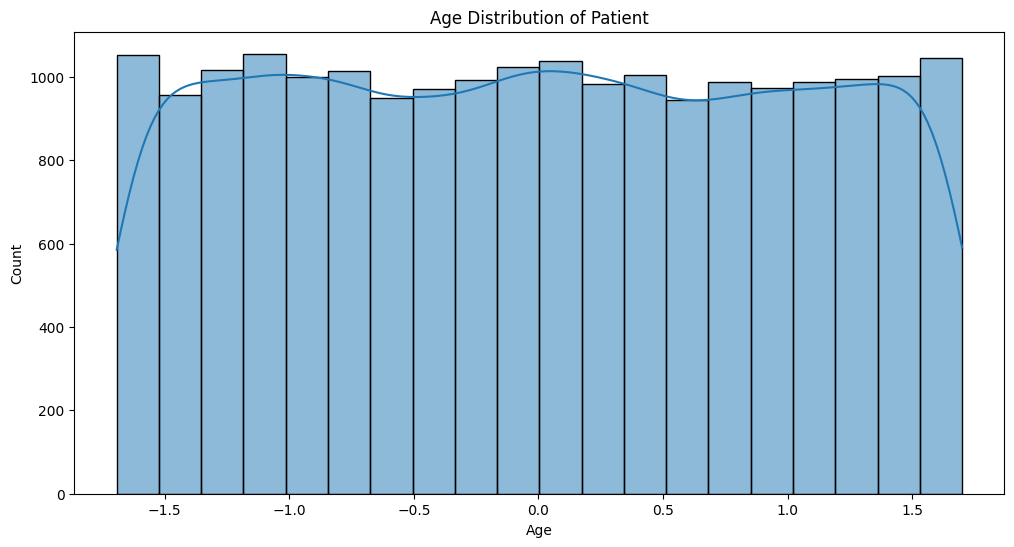

In [33]:
plt.figure(figsize=(12,6))
sb.histplot(df['Age'],bins = 20,kde= True)
plt.title('Age Distribution of Patient')
plt.show()

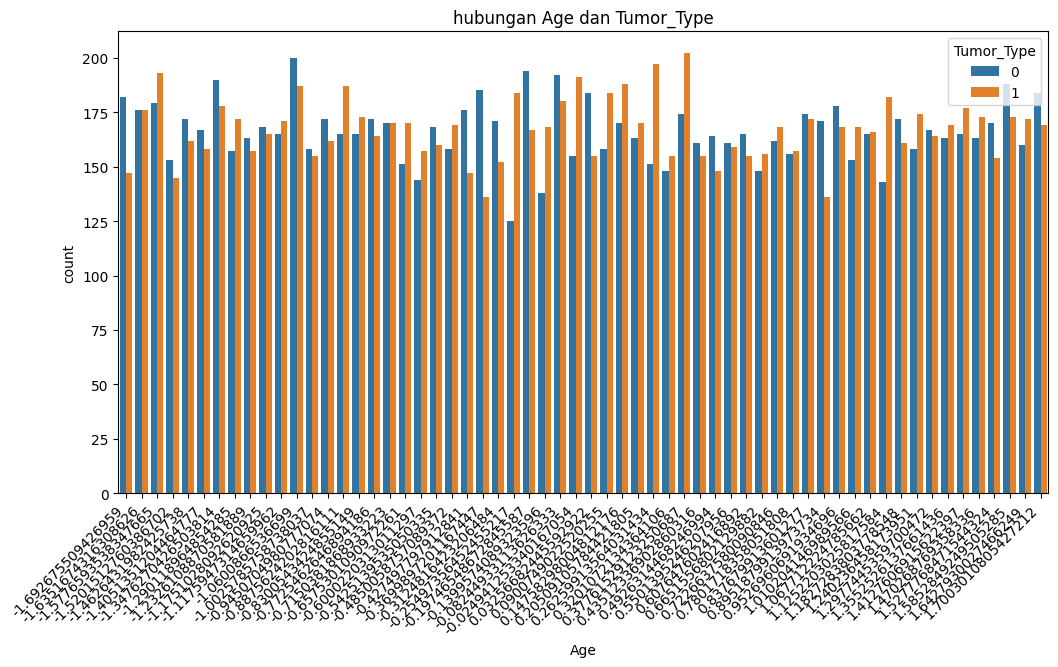

In [39]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Age', hue='Tumor_Type', data=df)  # Changed 'Tumor_type' to 'Tumor_Type'
plt.title('hubungan Age dan Tumor_Type')
plt.xticks(rotation=45, ha='right')
plt.show()

<ipython-input-40-180b1056f5b1>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=df, x='Tumor_Type', y='Age', palette='Set2')


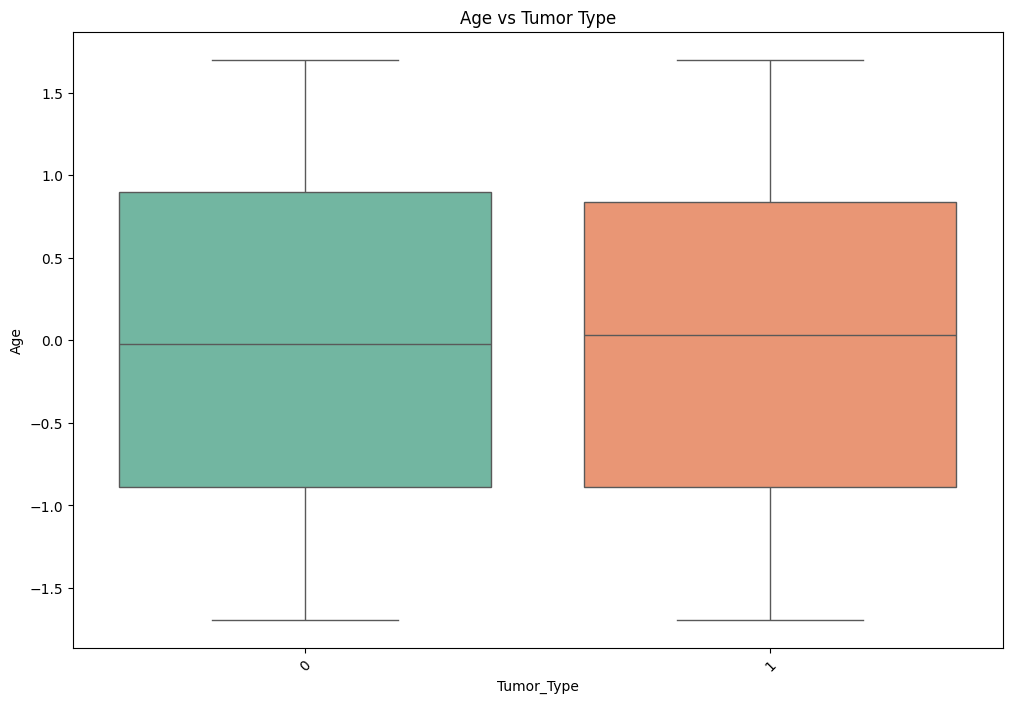

In [40]:
plt.figure(figsize=(12, 8))

sb.boxplot(data=df, x='Tumor_Type', y='Age', palette='Set2')
plt.title('Age vs Tumor Type')
plt.xticks(rotation=45)
plt.show()

<ipython-input-42-d90b301f981c>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Tumor_Type", y="Age", palette="muted")


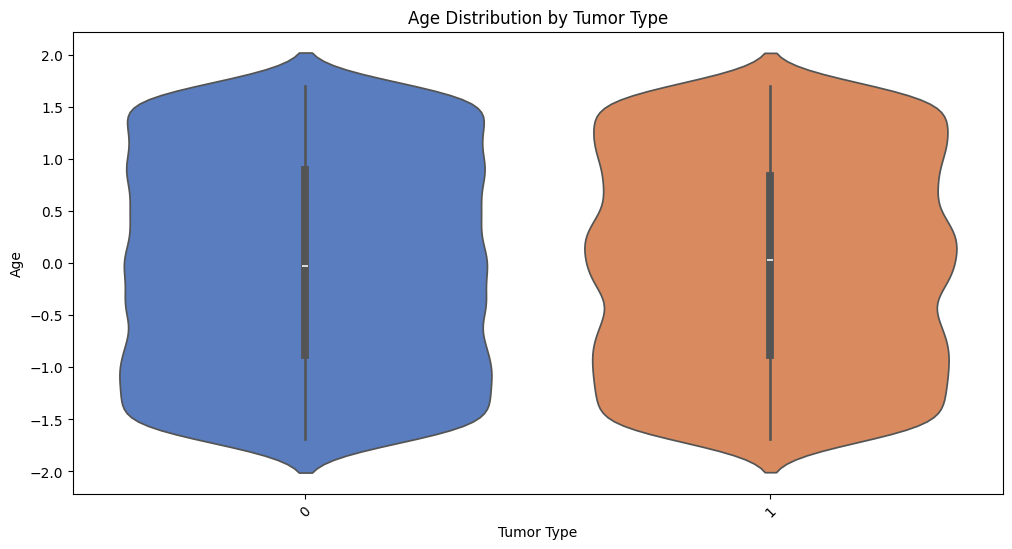

In [42]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x="Tumor_Type", y="Age", palette="muted")
plt.xticks(rotation=45)
plt.title("Age Distribution by Tumor Type")
plt.xlabel("Tumor Type")
plt.ylabel("Age")
plt.show()


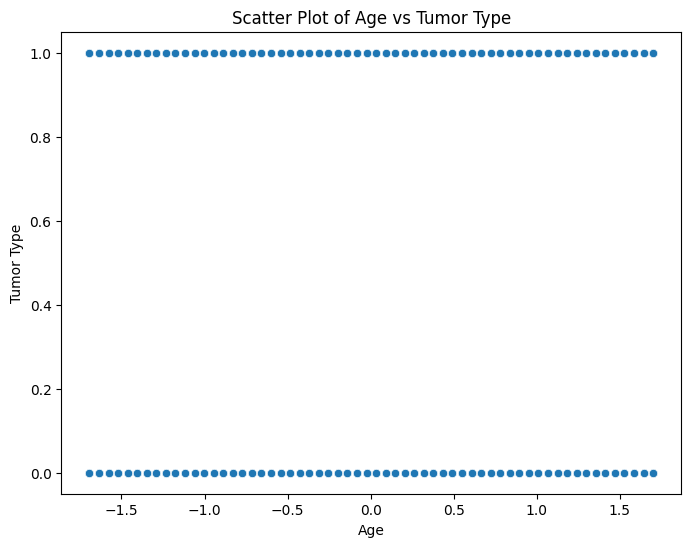

In [51]:
plt.figure(figsize=(8,6))
# Assuming 'Tumor_Type' is a suitable replacement for 'Gender' on the y-axis
sns.scatterplot(x='Age', y='Tumor_Type', data=df)
plt.title('Scatter Plot of Age vs Tumor Type') # Update the title to reflect the change
plt.xlabel('Age')
plt.ylabel('Tumor Type') # Update the y-axis label
plt.show()

# Data Preparation

In [9]:
existing_columns = df.columns

In [10]:
columns_to_drop = ['Patient_ID','Gender', 'Survival_Rate', 'Tumor_Growth_Rate','Family_History','Symptom_1', 'Symptom_2', 'Symptom_3']

In [11]:
columns_to_drop = [col for col in columns_to_drop if col in existing_columns]

In [12]:
df = df.drop(columns=columns_to_drop)

In [13]:
df.head()

,Age,Tumor_Type,Tumor_Size,Location,Histology,Stage,Radiation_Treatment,Surgery_Performed,Chemotherapy,MRI_Result,Follow_Up_Required
0,73,Malignant,5.375612,Temporal,Astrocytoma,III,No,No,No,Positive,Yes
1,26,Benign,4.847098,Parietal,Glioblastoma,II,Yes,Yes,Yes,Positive,Yes
2,31,Benign,5.588391,Parietal,Meningioma,I,No,No,No,Negative,No
3,29,Malignant,1.436600,Temporal,Medulloblastoma,IV,Yes,No,Yes,Negative,No
4,54,Benign,2.417506,Parietal,Glioblastoma,I,No,No,Yes,Positive,Yes


In [14]:
categorical_cols = ['Tumor_Type', 'Location', 'Histology', 'Stage',
                    'Radiation_Treatment', 'Surgery_Performed',
                    'Chemotherapy', 'MRI_Result']

In [15]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [16]:
df.head()

,Age,Tumor_Type,Tumor_Size,Location,Histology,Stage,Radiation_Treatment,Surgery_Performed,Chemotherapy,MRI_Result,Follow_Up_Required
0,73,1,5.375612,3,0,2,0,0,0,1,Yes
1,26,0,4.847098,2,1,1,1,1,1,1,Yes
2,31,0,5.588391,2,3,0,0,0,0,0,No
3,29,1,1.436600,3,2,3,1,0,1,0,No
4,54,0,2.417506,2,1,0,0,0,1,1,Yes


In [17]:
scaler = StandardScaler()
df[['Age', 'Tumor_Size']] = scaler.fit_transform(df[['Age', 'Tumor_Size']])

In [18]:
X = df.drop('Follow_Up_Required', axis=1)
y = LabelEncoder().fit_transform(df['Follow_Up_Required'])

In [19]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Changed x to X

In [55]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
#Normalisasi data
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Modeling

In [58]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(x_train.shape[1],)), # Change X_train to x_train
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(np.unique(y)), activation='softmax')  # jumlah kelas dinamis
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [60]:
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

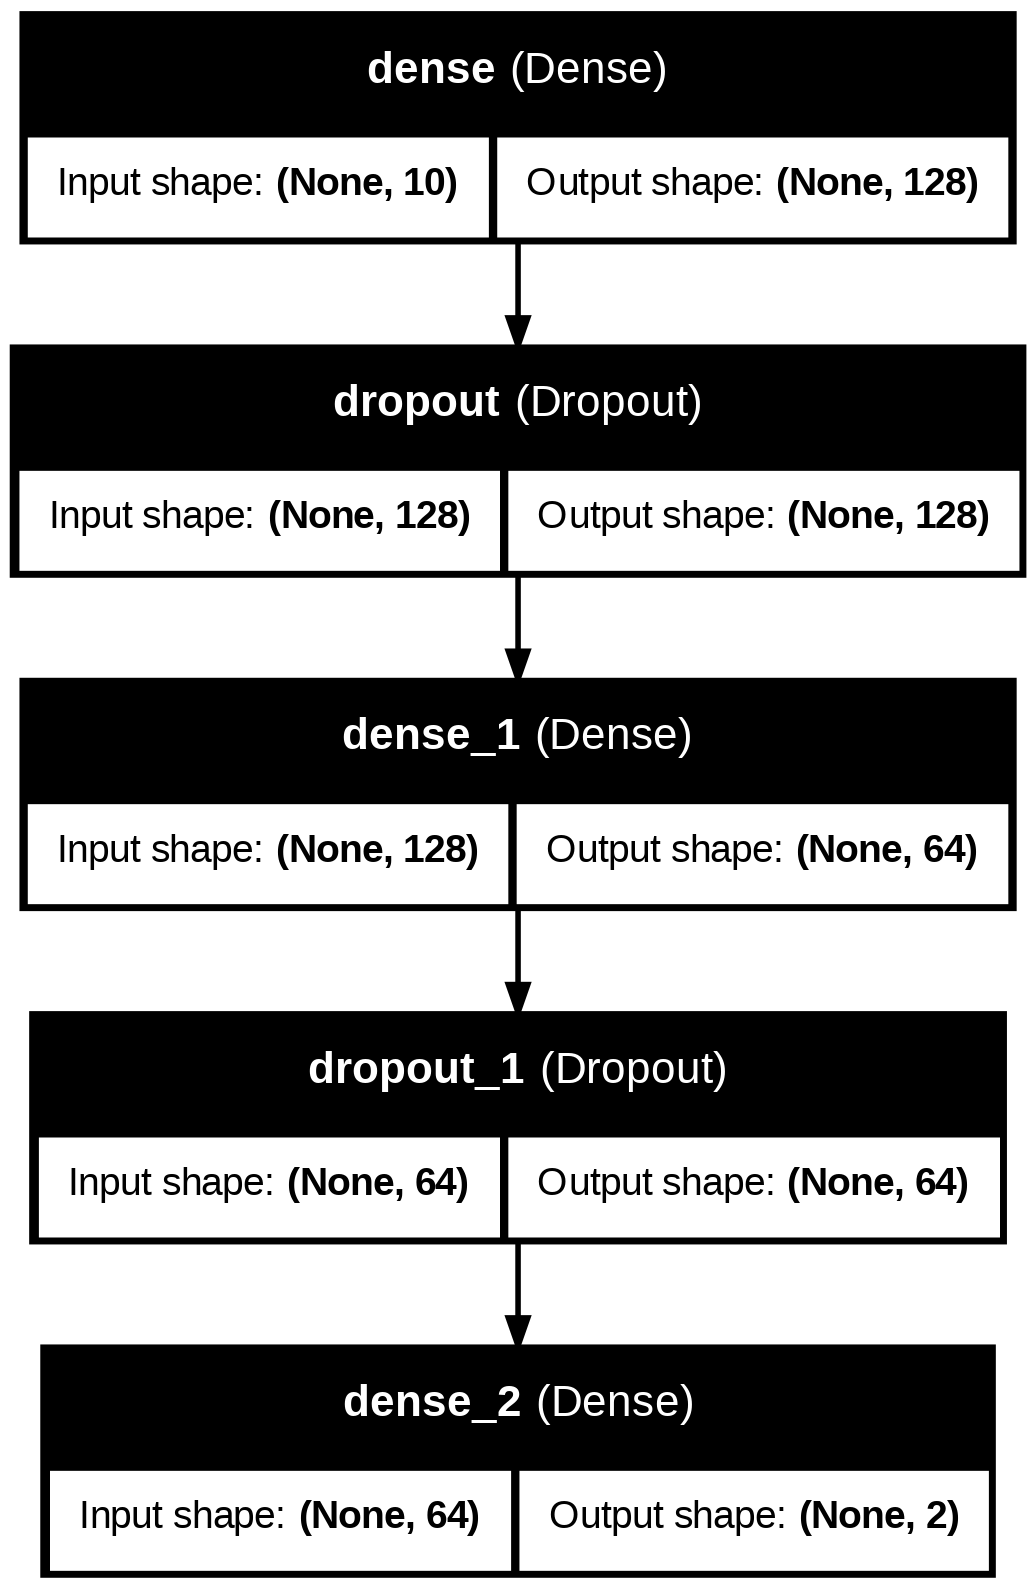

In [64]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True) # Now you can use plot_model

In [65]:
label_encoder = LabelEncoder()

In [66]:
# Assuming 'Follow_Up_Required' is the target column you want to encode
le = LabelEncoder() # Create a new LabelEncoder if you haven't already
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [73]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test),
                    epochs=50, batch_size=32, callbacks=[early_stop], verbose=0)

# Evaluation

In [70]:
y_pred = model.predict(x_test) # Changed X_test to x_test
y_pred_classes = np.argmax(y_pred, axis=1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [75]:
acc = accuracy_score(y_test, y_pred_classes)
print(f"Akurasi: {acc*170:.2f}%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_classes))

Akurasi: 86.83%
Confusion Matrix:
 [[ 144 1830]
 [ 127 1899]]


In [76]:
import matplotlib.pyplot as plt # Import the pyplot module from matplotlib

plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

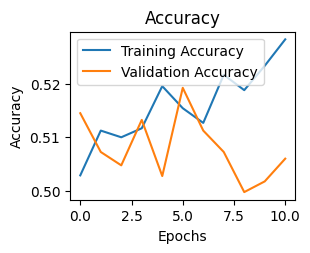

In [77]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

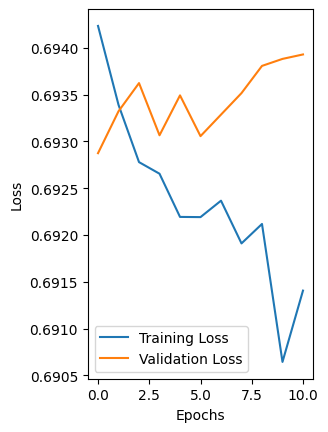

In [78]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


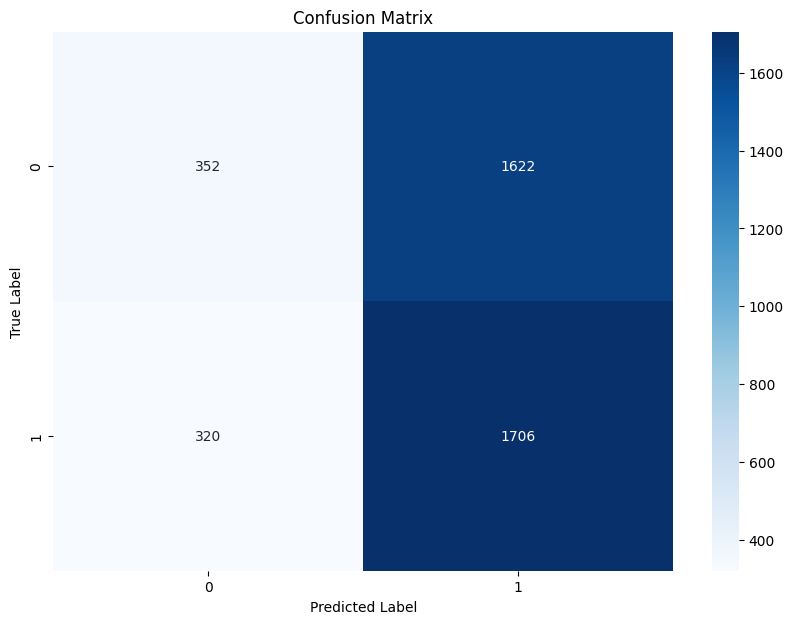

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.18      0.27      1974
           1       0.51      0.84      0.64      2026

    accuracy                           0.51      4000
   macro avg       0.52      0.51      0.45      4000
weighted avg       0.52      0.51      0.45      4000



In [79]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(x_test)  # Use x_test, not X_test
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

In [80]:
df.head()

,Age,Tumor_Type,Tumor_Size,Location,Histology,Stage,Radiation_Treatment,Surgery_Performed,Chemotherapy,MRI_Result,Follow_Up_Required
0,1.355253,1,0.050488,3,0,2,0,0,0,1,Yes
1,-1.347627,0,-0.141399,2,1,1,1,1,1,1,Yes
2,-1.060087,0,0.127742,2,3,0,0,0,0,0,No
3,-1.175103,1,-1.379648,3,2,3,1,0,1,0,No
4,0.262599,0,-1.023511,2,1,0,0,0,1,1,Yes


# Deployment

## Model Simulation

In [81]:
sample_input = np.array([[53, 1, 5.375612, 3, 1, 2,	0, 1, 0, 1]])
sample_input_df = pd.DataFrame(sample_input)

In [89]:
sample_input_scaled = scaler.transform(sample_input_df)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Save Model

In [90]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('Brain Tumor Dataset.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpg0m7lojf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  131933999881616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131933999882192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131933999884304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131933999882000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131933999881808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131933999884496: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [91]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']